<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Wrangling Lab**


Estimated time needed: **45** minutes


In this lab, you will perform data wrangling tasks to prepare raw data for analysis. Data wrangling involves cleaning, transforming, and organizing data into a structured format suitable for analysis. This lab focuses on tasks like identifying inconsistencies, encoding categorical variables, and feature transformation.


## Objectives


After completing this lab, you will be able to:


- Identify and remove inconsistent data entries.

- Encode categorical variables for analysis.

- Handle missing values using multiple imputation strategies.

- Apply feature scaling and transformation techniques.


#### Intsall the required libraries


In [1]:
!pip install pandas
!pip install matplotlib

## Tasks


#### Step 1: Import the necessary module.


### 1. Load the Dataset


<h5>1.1 Import necessary libraries and load the dataset.</h5>


Ensure the dataset is loaded correctly by displaying the first few rows.


In [2]:
# Import necessary libraries
import pandas as pd

# Load the Stack Overflow survey data
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(dataset_url)

# Display the first few rows
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

#### 2. Explore the Dataset


<h5>2.1 Summarize the dataset by displaying the column data types, counts, and missing values.</h5>


In [3]:
#display counts of data
df.shape

(65437, 114)

In [5]:
df.dtypes

ResponseId               int64
MainBranch              object
Age                     object
Employment              object
RemoteWork              object
                        ...   
JobSatPoints_11        float64
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

In [6]:
missing_data = df.isnull()  #look for null values
missing_data.head()         #print top 5 rows of data

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,False,False,False,False,False,False,False,False,False,True,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,False,False,True,True
3,False,False,False,False,True,False,True,False,False,False,...,True,True,True,True,True,True,False,False,True,True
4,False,False,False,False,True,False,True,False,False,False,...,True,True,True,True,True,True,False,False,True,True


<h5>2.2 Generate basic statistics for numerical columns.</h5>


In [8]:
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


### 3. Identifying and Removing Inconsistencies


<h5>3.1 Identify inconsistent or irrelevant entries in specific columns (e.g., Country).</h5>


In [9]:
#review top 20 data points
df['Country'].value_counts().head(20)


Country
United States of America                                11095
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
Ukraine                                                  2672
France                                                   2110
Canada                                                   2104
Poland                                                   1534
Netherlands                                              1449
Brazil                                                   1375
Italy                                                    1341
Australia                                                1260
Spain                                                    1123
Sweden                                                   1016
Russian Federation                                        925
Switzerland                                               876


In [10]:
#review bottom data points
df['Country'].value_counts().tail(20)


Country
Brunei Darussalam                        3
Democratic People's Republic of Korea    2
Mali                                     2
Guinea-Bissau                            2
Belize                                   2
Dominica                                 1
Papua New Guinea                         1
Equatorial Guinea                        1
Central African Republic                 1
Samoa                                    1
Niger                                    1
Guinea                                   1
Saint Kitts and Nevis                    1
Lesotho                                  1
Haiti                                    1
Micronesia, Federated States of...       1
Nauru                                    1
Chad                                     1
Djibouti                                 1
Solomon Islands                          1
Name: count, dtype: int64

In [11]:
#how many null values are in the data
df['Country'].isnull().sum()


np.int64(6507)

In [16]:
df['EdLevel'].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          24942
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       15557
Some college/university study without earning a degree                                 7651
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     5793
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2970
Associate degree (A.A., A.S., etc.)                                                    1793
Primary/elementary school                                                              1146
Something else                                                                          932
Name: count, dtype: int64

<h5>3.2 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format.</h5>


In [17]:
#strip trailing spaces on country
df['Country'] = df['Country'].str.strip()

In [19]:
#standardize education by creating one category for any preuniversity education
df['EdLevel'] = df['EdLevel'].replace({
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 
        'Pre-university education',
    'Primary/elementary school': 
        'Pre-university education'
})

df['EdLevel'].value_counts()


EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)              24942
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)           15557
Some college/university study without earning a degree     7651
Pre-university education                                   6939
Professional degree (JD, MD, Ph.D, Ed.D, etc.)             2970
Associate degree (A.A., A.S., etc.)                        1793
Something else                                              932
Name: count, dtype: int64

### 4. Encoding Categorical Variables


<h5>4.1 Encode the Employment column using one-hot encoding.</h5>


In [21]:
#Encode employment using one-hot encoding 
employment_encoded = pd.get_dummies(df['Employment'], prefix='Employment')

#validate change
df.filter(like='Employment_').head()


""
0
1
2
3
4


### 5. Handling Missing Values


<h5>5.1 Identify columns with the highest number of missing values.</h5>


In [23]:
missing_counts = df.isnull().sum()

missing_counts.sort_values(ascending=False).head(20)


AINextMuch less integrated       64289
AINextLess integrated            63082
AINextNo change                  52939
AINextMuch more integrated       51999
EmbeddedAdmired                  48704
EmbeddedWantToWorkWith           47837
EmbeddedHaveWorkedWith           43223
ConvertedCompYearly              42002
AIToolNot interested in Using    41023
AINextMore integrated            41009
Knowledge_9                      37802
Frequency_3                      37727
Knowledge_8                      37679
ProfessionalTech                 37673
Knowledge_7                      37659
Knowledge_6                      37573
Knowledge_5                      37557
Knowledge_2                      37416
Knowledge_4                      37407
Knowledge_3                      37342
dtype: int64

<h5>5.2 Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean or median.</h5>


In [38]:
#find average value
mean_value = df['ConvertedCompYearly'].value_counts().mean()

mean_value

np.float64(10.70281321557082)

In [39]:
import numpy as np

In [40]:
#replace null with mean value
df['ConvertedCompYearly'].replace(np.nan, mean_value, inplace=True )   #replace null value with mean value

/tmp/ipykernel_5120/2629830640.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ConvertedCompYearly'].replace(np.nan, mean_value, inplace=True )   #replace null value with mean value


In [35]:
#quick sanity check
df['ConvertedCompYearly'].value_counts()

ConvertedCompYearly
3.833633         42002
64444.000000       321
53703.000000       308
75184.000000       230
85925.000000       226
                 ...  
15637.000000         1
74970.000000         1
950000.000000        1
51448.000000         1
447569.000000        1
Name: count, Length: 6114, dtype: int64

<h5>5.3 Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value.</h5>


In [30]:
#find most frequent value
most_freq_value = df['ProfessionalTech'].value_counts().idxmax()

most_freq_value

'None of these'

In [31]:
#replace null with most frequent value
df['ProfessionalTech'].replace(np.nan, most_freq_value, inplace=True )   #replace null value with most freq value

/tmp/ipykernel_5120/2654295347.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ProfessionalTech'].replace(np.nan, most_freq_value, inplace=True )   #replace null value with most freq value


In [36]:
#sanity check
df['ProfessionalTech'].value_counts()

ProfessionalTech
None of these                                                                                                                                                                                                                                                                             40507
DevOps function;Automated testing;Observability tools;Knowledge sharing community;AI-assisted technology tool(s);Microservices;Developer portal or other central places to find tools/services;Continuous integration (CI) and (more often) continuous delivery;Innersource initiative     1068
DevOps function;Automated testing;Observability tools;Knowledge sharing community;AI-assisted technology tool(s);Microservices;Developer portal or other central places to find tools/services;Continuous integration (CI) and (more often) continuous delivery                             706
Automated testing;Continuous integration (CI) and (more often) continuous delivery                                     

### 6. Feature Scaling and Transformation


<h5>6.1 Apply Min-Max Scaling to normalize the `ConvertedCompYearly` column.</h5>


In [43]:
df_salary = df.dropna(subset=['ConvertedCompYearly']) #drop missing rows

In [44]:
#converted comp yearly has a large range, use min-max for scaling

df_salary.loc[:, 'ConvertedCompYearly_MinMax'] = (
    (df_salary['ConvertedCompYearly'] - df_salary['ConvertedCompYearly'].min()) /
    (df_salary['ConvertedCompYearly'].max() - df_salary['ConvertedCompYearly'].min())
)

<h5>6.2 Log-transform the ConvertedCompYearly column to reduce skewness.</h5>


In [46]:
!pip install seaborn     #install seaborn for chart

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

/opt/conda/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


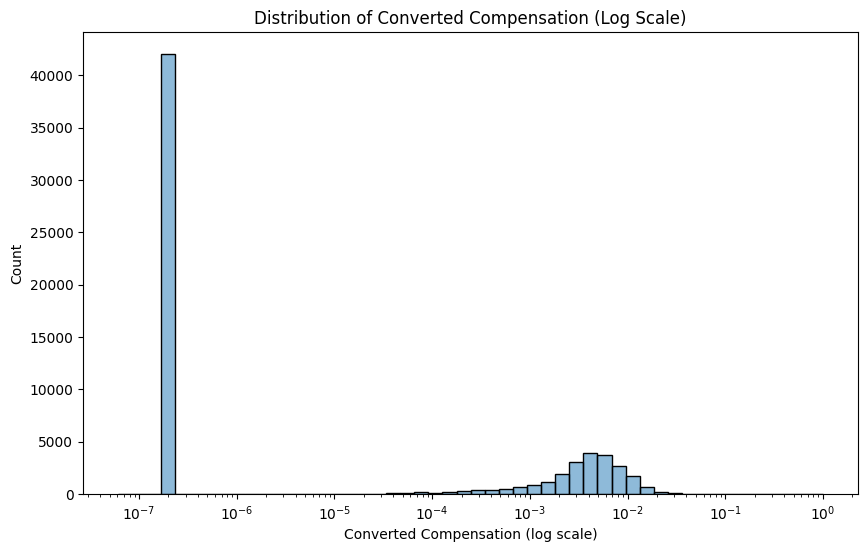

In [50]:
#create histogram for convertedcompyealyminmax

plt.figure(figsize=(10, 6))
sns.histplot(df_salary['ConvertedCompYearly_MinMax'], bins=50, kde=True, log_scale=True)
plt.title('Distribution of Converted Compensation (Log Scale)')                       #added in log scale to get a clearer picture
plt.xlabel('Converted Compensation (log scale)')
plt.ylabel('Count')
plt.show()

### 7. Feature Engineering


<h5>7.1 Create a new column `ExperienceLevel` based on the `YearsCodePro` column:</h5>


In [51]:
df['YearsCodePro'].value_counts()

YearsCodePro
2                     4168
3                     4093
5                     3526
10                    3251
4                     3215
Less than 1 year      2856
6                     2843
1                     2639
8                     2549
7                     2517
12                    1777
15                    1635
20                    1549
9                     1493
11                    1312
13                    1127
14                    1082
25                     998
16                     946
18                     867
17                     814
30                     689
24                     632
19                     516
22                     492
23                     448
26                     426
27                     380
21                     380
28                     342
35                     285
29                     196
40                     194
32                     194
34                     169
38                     134
33             

In [61]:
#replace change any alpha charcters to a numeric variable 
df['YearsCodePro_clean'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 50
}).astype(float)


In [62]:
#create formula for beginner intermediate and expert
import numpy as np

conditions = [
    df['YearsCodePro_clean'] <= 5,
    df['YearsCodePro_clean'].between(6, 20),
    df['YearsCodePro_clean'] > 20
]

choices = [
    'Beginner',
    'Intermediate',
    'Expert'
]

df['ExperienceLevel'] = np.select(conditions, choices, default='Unknown')



In [63]:
#sanity check
df['ExperienceLevel'].value_counts()


ExperienceLevel
Intermediate    24278
Beginner        20497
Unknown         13827
Expert           6835
Name: count, dtype: int64

### Summary


In this lab, you:

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.

- Engineered a new feature to enhance data interpretation.


Copyright © IBM Corporation. All rights reserved.
